![Ejercicio población](https://i.gyazo.com/2d36e3da376a77ba3bde79051a4639c9.jpg "Enunciado del problema de la población")

La solución es: [ 7.72691708e+13 -1.94873197e+11  1.96584034e+08 -9.91527225e+04
  2.50046792e+01 -2.52225000e-03]


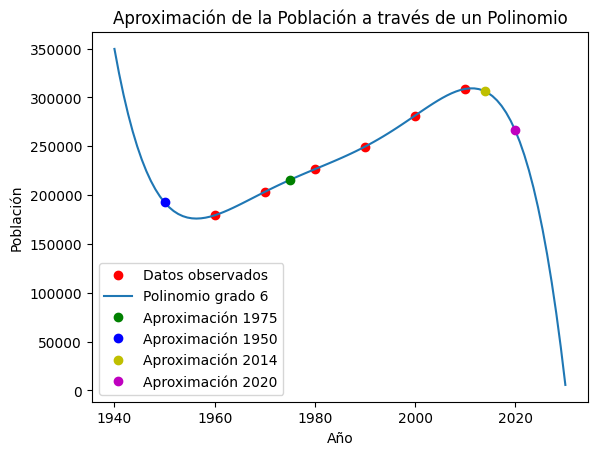

    Año   Aproximación         Real         Error
0  1950  192538.937500  150697360.0  1.505048e+08
1  1975  215525.718750          NaN           NaN
2  2014  306214.781250   31729800.0  3.142359e+07
3  2020  266164.984375          NaN           NaN


In [ ]:
#POLINOMIO GRADO N AUTOMATICOo
import numpy as np
import matplotlib.pyplot as plt
from metodo_gauss_seidel import gauss_seidel
from eliminacion_gaussiana_sin_pivoteo import eliminacion_gauus
import pandas as pd

#Funciones para resolver el problema
def Matrix(Px):
    """
    Genera la matriz de coeficientes para dar solución.
    ----------
    Parametros:
    -----------
    Px : array
        Vector de puntos x
    Retorna:
    --------
    A : array
        Matriz de coeficientes
    ----------
    """
    n = len(Px)

    A = np.zeros([n, n])
    for i in range(n):
        A[i, 0] = 1
        for j in range(1, n):
            A[i, j] = A[i, j-1] * Px[i]
    return A

def polynom_generator(coef, n):
    """
    Generador de polinomio de grado N.
    ----------
    Parametros:
    -----------
    n : int
        Grado del polinomio
    Retorna:
    --------
    pol_n : function
        Funcion que evalua el polinomio de grado N
    """
    pol_n = lambda x: sum([coef[i] * x**i for i in range(n)])
    return pol_n

#Datos del problema
Px = np.array([1960, 1970, 1980, 1990, 2000, 2010])
Ty = np.array([179323, 203302, 226542, 249633, 281422, 308746])
A = Matrix(Px)
b = Ty
x0 = np.zeros_like(b)
tol = 1e-6

# Solución de gauss seidel
# coef = gauss_seidel(A, b, x0, tol)
#Tocó con eliminación gaussina y esto me hace modificar algunos parámetros de las funciones.
coef = eliminacion_gauus(A, b)
print(f"La solución es: {coef}")

# PolN = lambda x: coef[0][0] + coef[0][1]*x + coef[0][2]*x**2 + coef[0][3]*x**3 + coef[0][4]*x**4 + coef[0][5]*x**5 + coef[0][6]*x**6

# Generarador de polinomio de grado N
# pol_n = lambda x: sum([coef[0][i] * x**i for i in range(len(coef[0]))])

#Graficar el problema
pol_n = polynom_generator(coef, len(coef))
# Se le restó y sumó 20 años más a los extremos para ver los picos de la gráfica
u_x = np.linspace(min(Px)-20, max(Px)+20, 100)
plt.plot(Px, Ty, 'or', label="Datos observados")
plt.plot(u_x, pol_n(u_x), label=f"Polinomio grado {len(coef)}")
#Graficar los puntos para visualizar diferencias
plt.plot(1975, pol_n(1975), 'og', label="Aproximación 1975")
plt.plot(1950, pol_n(1950), 'ob', label="Aproximación 1950")
plt.plot(2014, pol_n(2014), 'oy', label="Aproximación 2014")
plt.plot(2020, pol_n(2020), 'om', label="Aproximación 2020")
#
plt.xlabel("Año")
plt.ylabel("Población")
plt.title("Aproximación de la Población a través de un Polinomio")
plt.legend()
plt.show()

poblacion_1950 = pol_n(1950)
poblacion_2014 = pol_n(2014)
poblacion_1975 = pol_n(1975)
poblacion_2020 = pol_n(2020)
#Dataframe con las respuestas
data = {
    "Año": [1950, 1975, 2014, 2020],
    "Aproximación": [poblacion_1950, poblacion_1975, poblacion_2014, poblacion_2020],
    "Real": [150697360, None, 31729800, None],
    "Error": [
        abs(poblacion_1950 - 150697360),
        None,
        abs(poblacion_2014 - 31729800),
        None
    ]
}

df_resultados = pd.DataFrame(data)
print(df_resultados)